In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

train=pd.read_csv('train.csv')
test=pd.read_csv('test.csv')

In [2]:
train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [3]:
test.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
0,2011-01-20 00:00:00,1,0,1,1,10.66,11.365,56,26.0027
1,2011-01-20 01:00:00,1,0,1,1,10.66,13.635,56,0.0000
2,2011-01-20 02:00:00,1,0,1,1,10.66,13.635,56,0.0000
3,2011-01-20 03:00:00,1,0,1,1,10.66,12.880,56,11.0014
4,2011-01-20 04:00:00,1,0,1,1,10.66,12.880,56,11.0014


In [4]:
test.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed'],
      dtype='str')

In [5]:
train=train.drop(columns=['registered','casual'])

In [6]:
train.isnull().sum()

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
count         0
dtype: int64

In [7]:
train.duplicated().sum()

np.int64(0)

In [8]:
train.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'count'],
      dtype='str')

In [9]:
cols_value_counts=['season', 'holiday', 'workingday', 'weather']
for col in cols_value_counts:
    print(train[col].value_counts())

season
4    2734
2    2733
3    2733
1    2686
Name: count, dtype: int64
holiday
0    10575
1      311
Name: count, dtype: int64
workingday
1    7412
0    3474
Name: count, dtype: int64
weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64


In [10]:
train['datetime'].head()

0    2011-01-01 00:00:00
1    2011-01-01 01:00:00
2    2011-01-01 02:00:00
3    2011-01-01 03:00:00
4    2011-01-01 04:00:00
Name: datetime, dtype: str

In [11]:
train['datetime'] = pd.to_datetime(train['datetime'])

train['year'] = train['datetime'].dt.year
train['month'] = train['datetime'].dt.month
train['day'] = train['datetime'].dt.day
train['hour'] = train['datetime'].dt.hour
train['day_of_week'] = train['datetime'].dt.dayofweek

In [12]:
train.drop(columns=['datetime'],inplace =True)

In [13]:
X=train.drop(columns=['count'])
y=train['count']

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

<Axes: xlabel='count', ylabel='Count'>

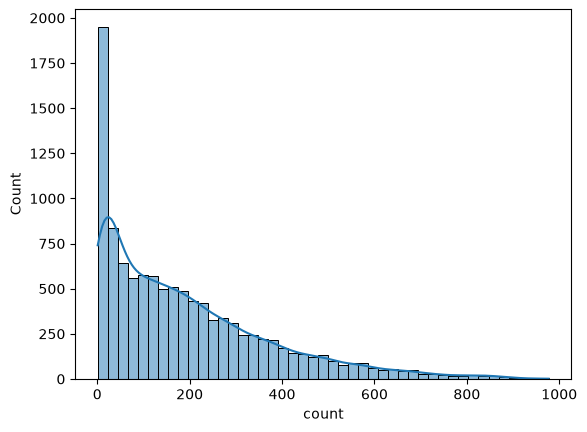

In [16]:
sns.histplot(train['count'], kde=True)

<Axes: xlabel='temp', ylabel='count'>

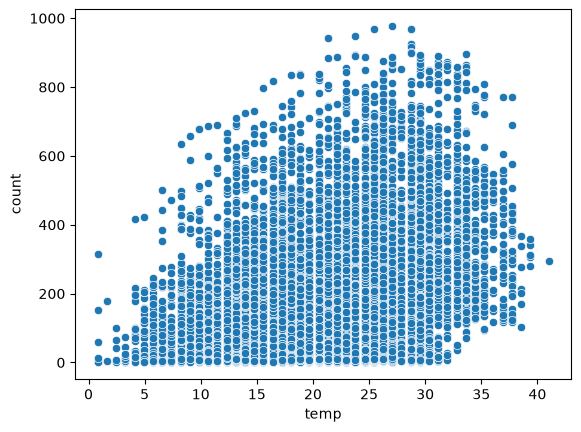

In [17]:
sns.scatterplot(data=train, x='temp', y='count')

<Axes: xlabel='humidity', ylabel='count'>

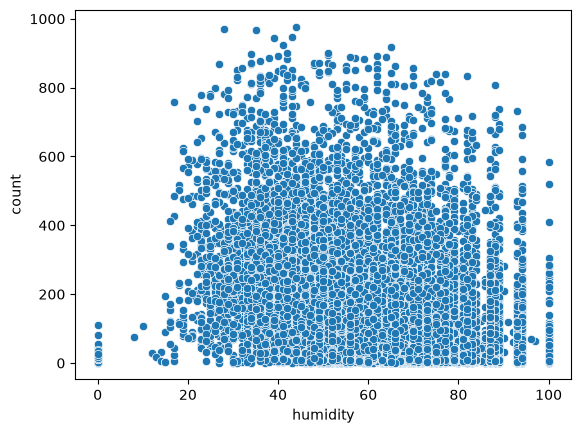

In [18]:
sns.scatterplot(data=train, x='humidity', y='count')

In [19]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error,r2_score

In [20]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [21]:
models_scaled={
    'Linear Regressor': LinearRegression(),
    'Ridge':Ridge(alpha=1.0),
}
models_unscaled={
    'Descision Tree': DecisionTreeRegressor(random_state=42,max_depth=5),
    'Random Forest':RandomForestRegressor(n_estimators=200, random_state=42,n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200,random_state=42)
}

results=[]

In [22]:
for name,model in models_scaled.items():
    model.fit(X_train_scaled,y_train)
    y_pred=model.predict(X_test_scaled)
    n, p = X_test_scaled.shape[0], X_test_scaled.shape[1] 
    r2=round(r2_score(y_test,y_pred),4)
    results.append({
        'Model':name,
        'RMSE': round(root_mean_squared_error(y_test,y_pred),4),
        'R2': r2,
        'R2_Adjust': (1 - ((1 - r2) * (n - 1)) / (n - p - 1))
    })
for name,model in models_unscaled.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    n, p = X_test.shape[0], X_test.shape[1] 
    r2=round(r2_score(y_test,y_pred),4)
    results.append({
        'Model':name,
        'RMSE': round(root_mean_squared_error(y_test,y_pred),4),
        'R2': r2,
        'R2_Adjust': (1 - ((1 - r2) * (n - 1)) / (n - p - 1))
    })
results_df=pd.DataFrame(results).sort_values(by='RMSE',ascending=True)
results_df

,Model,RMSE,R2,R2_Adjust
3,Random Forest,40.6649,0.9489,0.948714
4,Gradient Boosting,58.5774,0.8940,0.893615
2,Descision Tree,110.6251,0.6219,0.620527
1,Ridge,140.6881,0.3885,0.386279
0,Linear Regressor,140.6888,0.3885,0.386279


In [23]:
from sklearn.model_selection import GridSearchCV

In [24]:
param = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15],
    'min_samples_split': [2, 5]
}

grid=GridSearchCV(RandomForestRegressor(), param, cv=5, n_jobs=-1, scoring='neg_root_mean_squared_error')

In [25]:
grid.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 15], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0

In [26]:
best_params=grid.best_params_
final_model=grid.best_estimator_

In [27]:
y_pred=final_model.predict(X_test)
r2_score(y_test,y_pred)

0.9479932010910932

In [28]:
root_mean_squared_error(y_test,y_pred)

41.03029034484342

In [29]:
test['datetime'] = pd.to_datetime(test['datetime'])

test['year'] = test['datetime'].dt.year
test['month'] = test['datetime'].dt.month
test['day'] = test['datetime'].dt.day
test['hour'] = test['datetime'].dt.hour
test['day_of_week'] = test['datetime'].dt.dayofweek

test_datetime=test['datetime']
test.drop(columns=['datetime'],inplace=True)
expected_cols=X.columns
test=test[expected_cols]

In [30]:
print(X.columns.tolist())
print(test.columns.tolist())

['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'year', 'month', 'day', 'hour', 'day_of_week']
['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'year', 'month', 'day', 'hour', 'day_of_week']


In [31]:
predictions=final_model.predict(test)

submission=pd.DataFrame({
    'datetime':test_datetime,
    'count': predictions
})

In [32]:
submission.to_csv('submission.csv',index=False)

In [33]:
import joblib

joblib.dump(final_model, 'bike_demand_model.pkl')
joblib.dump(X.columns.tolist(), 'bike_expected_cols.pkl')
joblib.dump(scaler,'bike_demand_scaler.pkl')

['bike_demand_scaler.pkl']

In [34]:
X.columns

Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'year', 'month', 'day', 'hour', 'day_of_week'],
      dtype='str')